In [1]:
import os
import pandas as pd
import re

# Define the root directory path
root_directory = "/home/sem23/fastrocs/rp1-sem-egbers/DrugEx_script/"

# Get the list of directories containing the files
directories = []

# Iterate through all folders in the root directory
for dirpath, dirnames, filenames in os.walk(root_directory):
    for dirname in dirnames:
        # Check if the directory name contains "NS" and "eps" and doesn't contain "bs256"
        if "ns" in dirname and "eps" in dirname: #and "bs256" not in dirname:
            directories.append(os.path.join(dirpath, dirname))

# Sort the directories based on 'ns' and 'eps' values from low to high
directories.sort(key=lambda x: (int(x.split('_')[2][2:]), float(x.split('_')[3][3:]),int(x.split('_')[4][4:])))

# Create a dictionary to store the IDs
id_counter = 1
id_mapping = {}

# Iterate through each directory and assign an ID
# for directory in directories:
#     id_mapping[directory] = f"ID_{id_counter}" # parse information with ns, eps and bs 
#     id_counter += 1
# Iterate through each directory and assign an ID
for directory in directories:
    ns_value = directory.split('_')[2][2:]  
    eps_value = directory.split('_')[3][3:] 
    bs_value = directory.split('_')[4]      
    id_mapping[directory] = f"ID_{id_counter}_ns{ns_value}_eps{eps_value}_{bs_value}"
    id_counter += 1

# Remove RL in name and add whole name to each data input 
# Iterate through each directory, locate the TSV files, and read them into a DataFrame
dataframes = []
fit_dataframes = []


for directory, directory_id in id_mapping.items():
    # Construct the full file path
    file_path = os.path.join(directory, "CCR2_agent_smiles.tsv")
    fit_path = os.path.join(directory, "CCR2_agent_fit.tsv") 
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep='\t')
        df1 = pd.read_csv(fit_path, sep='\t')
        # Assign directory ID to each row in the DataFrame
        df['ID'] = directory_id
        df1['ID'] = directory_id
        dataframes.append(df) #df1
        fit_dataframes.append(df1) 
    
#Concatenate these DataFrames into one
combined_df = pd.concat(dataframes, ignore_index=True)
fit_df = pd.concat(fit_dataframes, ignore_index=True)

for directory, directory_id in id_mapping.items():
    # Extract NS and eps values from the directory path
    ns_value = directory.split('_')[2]
    eps_value = directory.split('_')[3]
    bs_value = directory.split('_')[4]
    print(f"ID: {directory_id}, ns: {ns_value}, eps: {eps_value}, bs: {bs_value}")



ID: ID_1_ns1000_eps0.01_bs128, ns: ns1000, eps: eps0.01, bs: bs128
ID: ID_2_ns1000_eps0.1_bs128, ns: ns1000, eps: eps0.1, bs: bs128
ID: ID_3_ns1000_eps0.2_bs128, ns: ns1000, eps: eps0.2, bs: bs128
ID: ID_4_ns1000_eps0.3_bs128, ns: ns1000, eps: eps0.3, bs: bs128
ID: ID_5_ns1000_eps0.4_bs128, ns: ns1000, eps: eps0.4, bs: bs128
ID: ID_6_ns10000_eps0.01_bs256, ns: ns10000, eps: eps0.01, bs: bs256
ID: ID_7_ns10000_eps0.01_bs128, ns: ns10000, eps: eps0.01, bs: bs128
ID: ID_8_ns10000_eps0.1_bs256, ns: ns10000, eps: eps0.1, bs: bs256
ID: ID_9_ns10000_eps0.1_bs128, ns: ns10000, eps: eps0.1, bs: bs128
ID: ID_10_ns10000_eps0.2_bs256, ns: ns10000, eps: eps0.2, bs: bs256
ID: ID_11_ns10000_eps0.2_bs128, ns: ns10000, eps: eps0.2, bs: bs128
ID: ID_12_ns10000_eps0.3_bs256, ns: ns10000, eps: eps0.3, bs: bs256
ID: ID_13_ns10000_eps0.3_bs128, ns: ns10000, eps: eps0.3, bs: bs128
ID: ID_14_ns10000_eps0.4_bs256, ns: ns10000, eps: eps0.4, bs: bs256
ID: ID_15_ns10000_eps0.4_bs128, ns: ns10000, eps: eps0.4, bs:

ID selection and filtering

In [2]:
# Initialize a list to store IDs with bs256
bs256_ids = []

# Iterate over the keys of id_mapping dictionary
for directory, directory_id in id_mapping.items():
    # Check if the directory ID contains 'bs256'
    if 'bs256' in directory_id:
        # Append the directory ID to the list
        bs256_ids.append(directory_id)

# bs256_ids now contains all the IDs with 'bs256'


In [8]:
# Define the list of IDs to iterate over
target_data = bs256_ids
# Dictionary to store the filtered DataFrames for the last epoch of each ID
last_epoch_dfs = {}

# Columns to keep
columns_to_keep = ['SMILES', 'ROCS', 'SA', 'Epoch']

# Iterate over each ID
for id_ in target_data:
    # Filter the DataFrame for the current ID
    id_df = fit_df[fit_df['ID'] == id_]
    
    # Find the maximum epoch value for the current ID
    max_epoch_value = id_df['best_epoch'].max()
    
    # Filter out the rows with the highest epoch value in the 'Epoch' column
    filtered_df = combined_df[combined_df['Epoch'] == max_epoch_value]
  
    # Keep only the specified columns
    last_epoch_df = filtered_df[columns_to_keep]
    
    # Store the DataFrame for the last epoch in the dictionary
    last_epoch_df['ID'] = id_
    last_epoch_dfs[id_] = last_epoch_df
    
epoch_all = pd.concat(last_epoch_dfs.values())
print(epoch_all)
    

# Accessing individual DataFrames
# id_6_df = last_epoch_dfs['ID_6']
# id_7_df = last_epoch_dfs['ID_7']




                                                   SMILES   ROCS     SA  \
10400            COc1ccc(S(=O)(=O)Nc2ccccc2OCc2ccccc2)cc1  0.420  0.991   
10401           c1cccc(Oc2ccc(-c3ccc(-c4ccccc4)cc3)cc2)c1  0.305  0.996   
10402          Cc1ccc(C(=O)c2nc3cc(O)ccc3n2Cc2ccccc2C)cc1  0.576  0.975   
10403               Cc1ccc(Cc2nc3cc(N)ccc3n2Cc2ccccn2)cc1  0.564  0.978   
10404         COc1ccc(Oc2ncccc2NS(=O)(=O)c2ccc(Cl)cc2)cc1  0.482  0.985   
...                                                   ...    ...    ...   
945395  COc1ncc(Cl)nc1Sc1ccc(Cl)cc1NS(=O)(=O)c1ccc(Cl)...  0.450  0.914   
945396  CN(C)C(=O)C1CN(c2ccccc2)CCN1C(=O)c1ccc(C(F)(F)...  0.394  0.918   
945397  CC1CCN(C(=O)c2cc3ccccc3n2C)=C(OS(=O)(=O)c2cccc...  0.000  0.000   
945398                      Cc1ccc(NC(=O)Cc2ccc(F)cc2)cc1  0.243  0.995   
945399       CC(=O)C1=C(O)C(=O)N(c2ccc(C)cc2F)C1Cc1ccccc1  0.410  0.923   

        Epoch                          ID  
10400     105  ID_6_ns10000_eps0.01_bs256  
10401     1

ROCS per epoch Visualisation

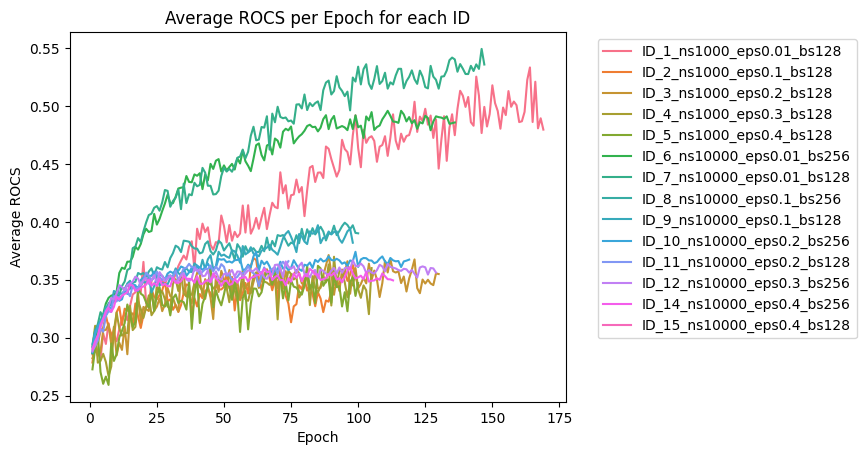

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group by 'Epoch' and calculate the mean of 'ROCS' for each epoch
average_rocs_per_epoch = combined_df.groupby(['ID','Epoch'])['ROCS'].mean().reset_index()

# Get the unique IDs and sort them
unique_ids = average_rocs_per_epoch['ID'].unique()
sorted_ids = sorted(unique_ids, key=lambda x: int(x.split('_')[1]))

# Plotting
sns.lineplot(data=average_rocs_per_epoch, x='Epoch', y='ROCS', hue='ID', hue_order=sorted_ids)

plt.xlabel('Epoch')
plt.ylabel('Average ROCS')
plt.title('Average ROCS per Epoch for each ID')

# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.show()


Scatterplot overview of selected ID's to visualise chemical space

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from qsprpred.data.descriptors.fingerprints import MorganFP
from scaffviz.clustering.manifold import TSNE
from qsprpred.data.sources.papyrus import Papyrus
from scaffviz.depiction.plot import Plot
from qsprpred.data.tables.mol import MoleculeTable

# Assuming you have a DataFrame called 'dataset' with the required data
# Add Morgan fingerprints to the dataset
dataset = MoleculeTable('ID_best_epoch', epoch_all, overwrite=True)
dataset.addDescriptors([MorganFP(radius=3, nBits=2048)], recalculate=False)
print(dataset)
# Perform t-SNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
tsne_data = tsne.fit_transform(dataset.getDescriptors())  

 




In [13]:
tsne_data[:,0]

array([-21.936441,  35.481037,  66.98929 , ...,  27.228956, -35.91402 ,
         6.147741], dtype=float32)

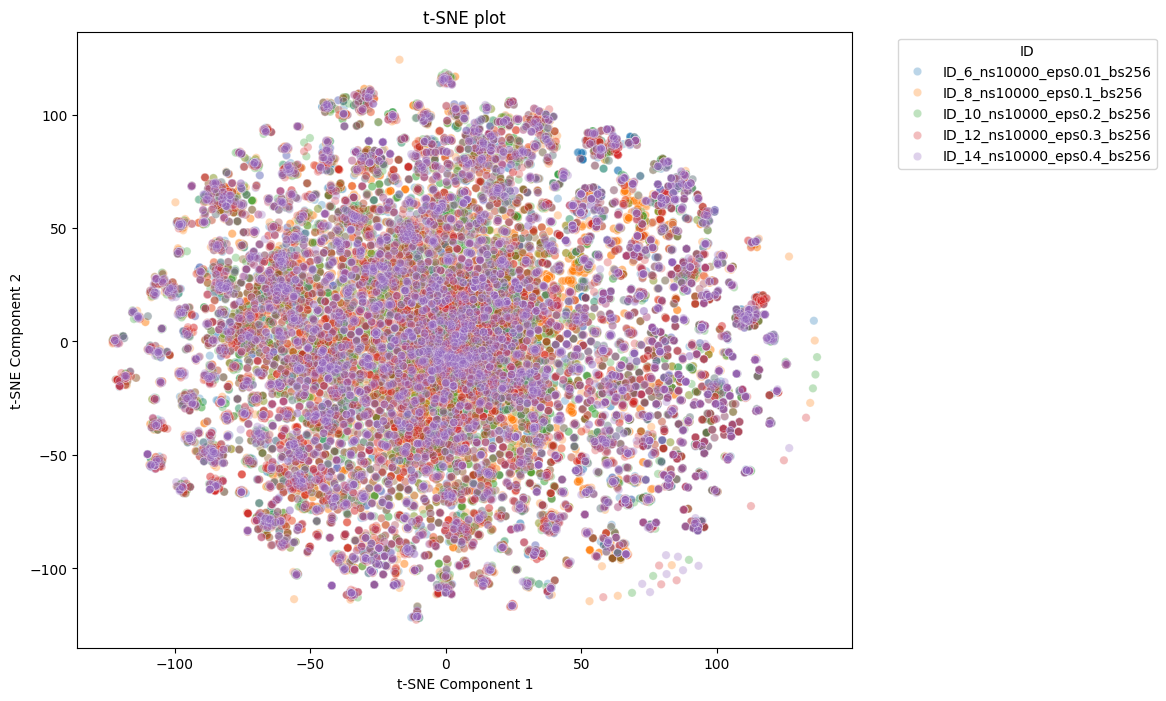

In [30]:
# Create a DataFrame with the t-SNE results
dataset.addProperty("TSNE_1", tsne_data[:,0])
dataset.addProperty("TSNE_2", tsne_data[:,1])

tsne_df = dataset.getDF() 

# Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(data=tsne_df, x='TSNE_1', y='TSNE_2', hue='ID', alpha=0.3)

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE plot')

# Show the plot
# plt.legend(title='ID', loc='upper right')
plt.legend(title='ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [26]:
tsne_df['ID'].str.startswith('ID_6')

QSPRID
ID_best_epoch_00000     True
ID_best_epoch_00001     True
ID_best_epoch_00002     True
ID_best_epoch_00003     True
ID_best_epoch_00004     True
                       ...  
ID_best_epoch_35778    False
ID_best_epoch_35779    False
ID_best_epoch_35780    False
ID_best_epoch_35781    False
ID_best_epoch_35782    False
Name: ID, Length: 35783, dtype: bool

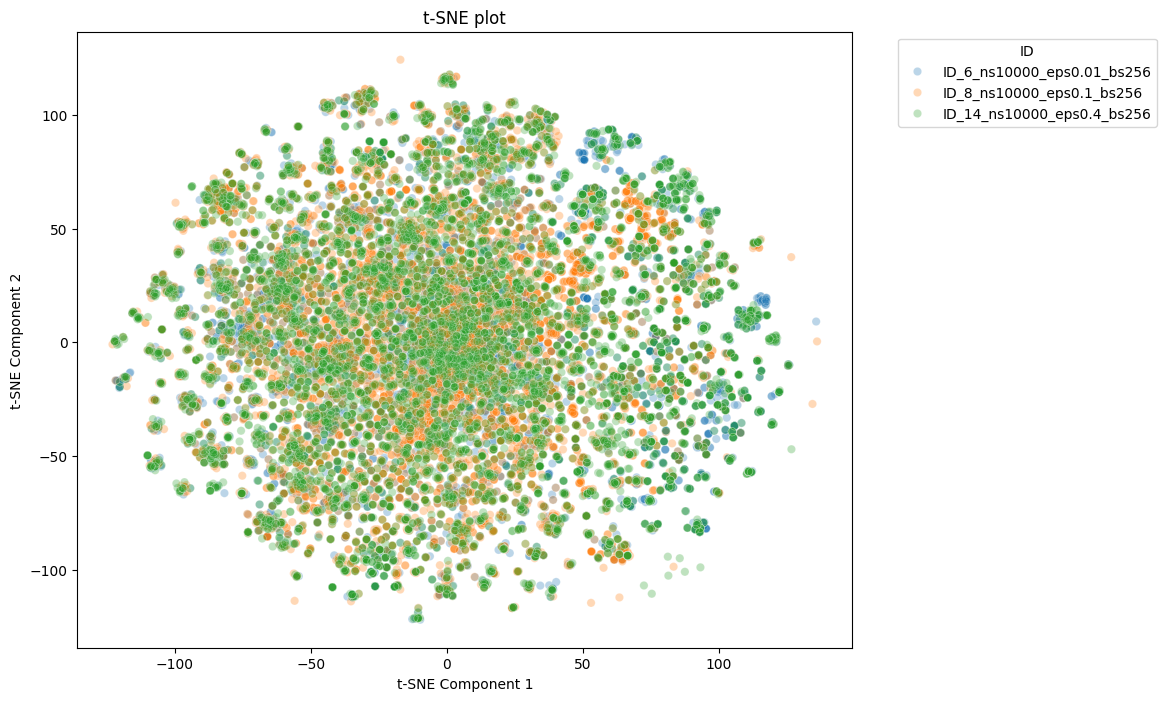

In [31]:
tsne_df_1 = tsne_df[tsne_df["ID"].str.startswith("ID_6")|tsne_df['ID'].str.startswith('ID_8')|tsne_df['ID'].str.startswith('ID_14')]

# Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(data=tsne_df_1, x='TSNE_1', y='TSNE_2', hue='ID', alpha=0.3)

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE plot')

# Show the plot
# plt.legend(title='ID', loc='upper right')
plt.legend(title='ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

/tmp/ipykernel_2691474/210239255.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['ID'] = pd.Categorical(filtered_data['ID'], categories=id_order, ordered=True)


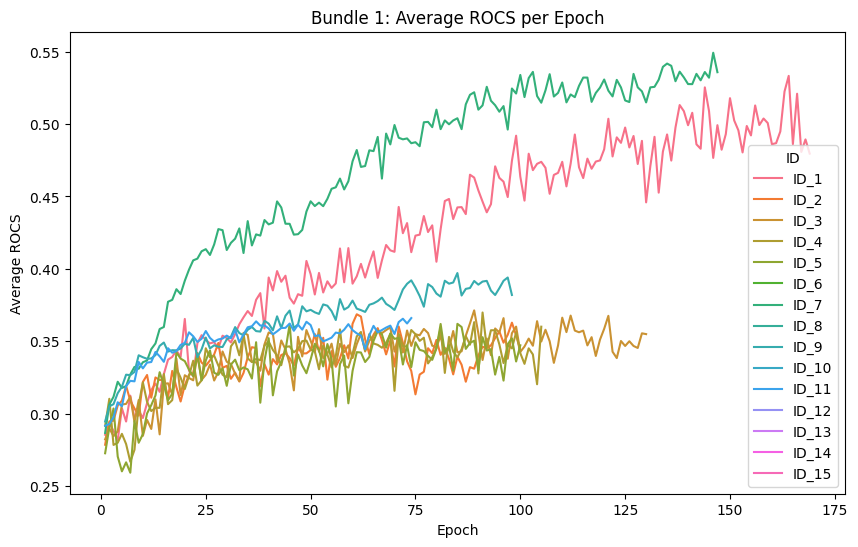

/tmp/ipykernel_2691474/210239255.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['ID'] = pd.Categorical(filtered_data['ID'], categories=id_order, ordered=True)


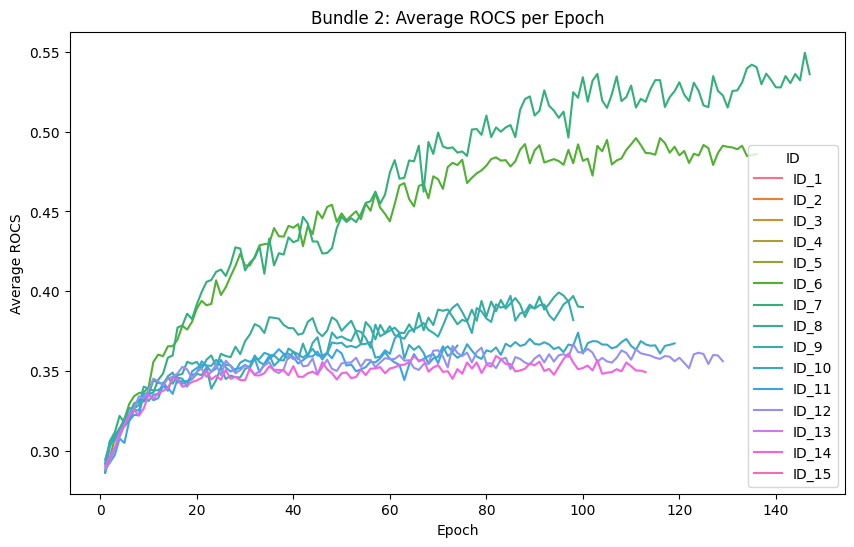

/tmp/ipykernel_2691474/210239255.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['ID'] = pd.Categorical(filtered_data['ID'], categories=id_order, ordered=True)


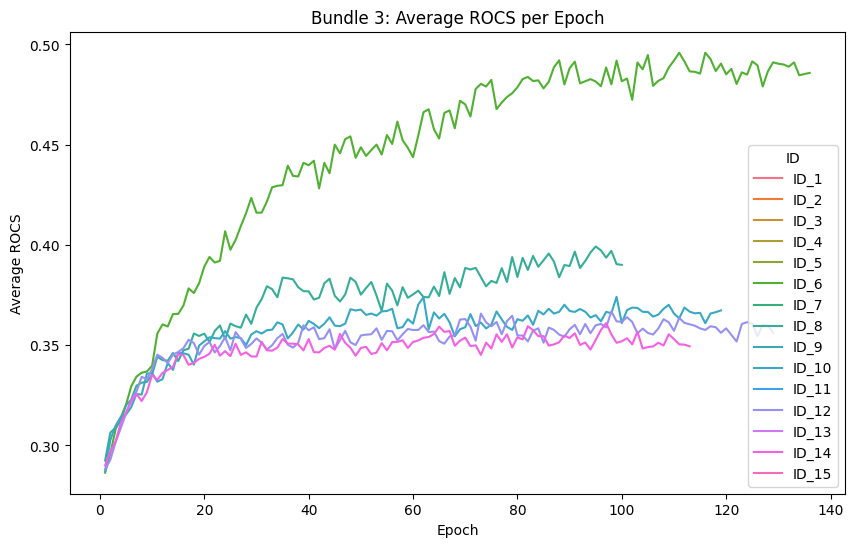

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the bundles of IDs
id_bundles = [
    ['ID_1', 'ID_2', 'ID_3','ID_4','ID_5','ID_7','ID_9','ID_11','ID_13','ID_15'],
    ['ID_6', 'ID_7', 'ID_8','ID_9','ID_10','ID_11','ID_12','ID_13','ID_14','ID_15'],
    ['ID_6', 'ID_8', 'ID_10','ID_12','ID_14']
]

# Define the order of IDs
id_order = [f'ID_{i}' for i in range(1, 16)]

# Iterate over each bundle of IDs
for i, ids in enumerate(id_bundles, 1):
    # Filter the DataFrame to include only the specified IDs
    filtered_data = average_rocs_per_epoch[average_rocs_per_epoch['ID'].isin(ids)]
    
    # Set the categorical order of the 'ID' column
    filtered_data['ID'] = pd.Categorical(filtered_data['ID'], categories=id_order, ordered=True)
    
    # Create a new figure for each bundle of IDs
    plt.figure(figsize=(10, 6))  # Adjust the figure size as needed
    sns.lineplot(data=filtered_data, x='Epoch', y='ROCS', hue='ID')
    plt.xlabel('Epoch')
    plt.ylabel('Average ROCS')
    plt.title(f'Bundle {i}: Average ROCS per Epoch')
    plt.legend(title='ID')
    plt.show()



Interactive plot calculated with moldescriptors

In [9]:
import pandas as pd 

 
from qsprpred.data.chem.scaffolds import BemisMurcko
from qsprpred.data.descriptors.fingerprints import MorganFP
from scaffviz.clustering.manifold import TSNE
from qsprpred.data.sources.papyrus import Papyrus
from scaffviz.depiction.plot import Plot
from qsprpred.data.tables.mol import MoleculeTable


dataset = MoleculeTable('ID_6', id_6_df, overwrite=True)

# add generic scaffolds to the data set
# these will be used to group the molecules
dataset.addScaffolds([BemisMurcko()])

# add Morgan fingerprints to the data set
# these will be used to calculate the t-SNE embedding in 2D
dataset.addDescriptors([MorganFP(radius=3, nBits=2048)], recalculate=False)

# make an interactive plot that will use t-SNE to embed the data set in 2D
# (all available descriptors in the data set will be used, not just selected features)
plt = Plot(TSNE(perplexity=50))
plt.plot(
    dataset,
    recalculate=False,
    color_by='ROCS', 
    card_data=["ROCS","SA"],  # what to show on the molecule cards
    title_data='Molecules'   # Data to show in the title of the molecule cards
)

/home/sem23/miniconda3/envs/oepython/lib/python3.11/site-packages/dash/dash.py:556: UserWarning:

JupyterDash is deprecated, use Dash instead.
See https://dash.plotly.com/dash-in-jupyter for more details.



TypeError: 'NoneType' object cannot be interpreted as an integer

In [10]:
dataset.getDF()
sns.plot()

,SMILES,ROCS,SA,Epoch,QSPRID,Scaffold_Bemis-Murcko,TSNE_1,TSNE_2
QSPRID,,,,,,,,
ID_6_0000,COc1ccc(S(=O)(=O)Nc2ccccc2OCc2ccccc2)cc1,0.420,0.991,105,ID_6_0000,*=S(=*)(Nc1ccccc1OCc1ccccc1)c1ccccc1,-55.639706,32.596615
ID_6_0001,c1cccc(Oc2ccc(-c3ccc(-c4ccccc4)cc3)cc2)c1,0.305,0.996,105,ID_6_0001,c1ccc(Oc2ccc(-c3ccc(-c4ccccc4)cc3)cc2)cc1,-19.965616,-11.435893
ID_6_0002,Cc1ccc(C(=O)c2nc3cc(O)ccc3n2Cc2ccccc2C)cc1,0.576,0.975,105,ID_6_0002,*=C(c1ccccc1)c1nc2ccccc2n1Cc1ccccc1,62.693462,-28.996700
ID_6_0003,Cc1ccc(Cc2nc3cc(N)ccc3n2Cc2ccccn2)cc1,0.564,0.978,105,ID_6_0003,c1ccc(Cc2nc3ccccc3n2Cc2ccccn2)cc1,38.922298,-32.033546
ID_6_0004,COc1ccc(Oc2ncccc2NS(=O)(=O)c2ccc(Cl)cc2)cc1,0.482,0.985,105,ID_6_0004,*=S(=*)(Nc1cccnc1Oc1ccccc1)c1ccccc1,-27.076254,45.855873
...,...,...,...,...,...,...,...,...
ID_6_5222,Cc1cccc(CNC(=O)c2ccc(Oc3ccccc3)cc2)n1,0.279,0.989,105,ID_6_5222,*=C(NCc1ccccn1)c1ccc(Oc2ccccc2)cc1,-15.940393,-7.093226
ID_6_5223,CC(C)(C)c1ccc(S(=O)(=O)Nc2ccc(Cl)cc2-c2ncccc2N...,0.409,0.964,105,ID_6_5223,*=S(=*)(Nc1ccccc1-c1ncccc1N1CCCC1)c1ccccc1,10.044570,35.308426
ID_6_5224,O=C(C1CC1)N1c2ccccc2Oc2ccccc21,0.337,0.977,105,ID_6_5224,*=C(C1CC1)N1c2ccccc2Oc2ccccc21,-1.917748,8.741977


Mols2grid viewers

In [5]:
# I want to portray here the top 50 smiles of ID1, ID6 and ID7

import pandas as pd 
import rdkit 
from rdkit import Chem
from rdkit.Chem import Draw
import mols2grid


# specific_variable_name = "df_ranked_1"

# # Check if the variable name exists in the dictionary
# if specific_variable_name in result_dataframes:
#     specific_dataframe = result_dataframes[specific_variable_name]

mols2grid.display(id_1_df.head(50), smiles_col='SMILES', subset=['ROCS','SA'], tooltip=["SMILES", "ROCS", "SA"])




MolGridWidget()

In [5]:
# I want to portray here the top 50 smiles of ID1, ID6 and ID7

import pandas as pd 
import rdkit 
from rdkit import Chem
from rdkit.Chem import Draw
import mols2grid


# specific_variable_name = "df_ranked_1"

# # Check if the variable name exists in the dictionary
# if specific_variable_name in result_dataframes:
#     specific_dataframe = result_dataframes[specific_variable_name]

mols2grid.display(id_6_df, smiles_col='SMILES', subset=['ROCS','SA'], tooltip=["SMILES", "ROCS", "SA"])




MolGridWidget()

In [7]:
# I want to portray here the top 50 smiles of ID1, ID6 and ID7

import pandas as pd 
import rdkit 
from rdkit import Chem
from rdkit.Chem import Draw
import mols2grid



mols2grid.display(id_7_df, smiles_col='SMILES', subset=['ROCS','SA'], tooltip=["SMILES", "ROCS", "SA"])




MolGridWidget()

Visualisation of Desired ratio progression

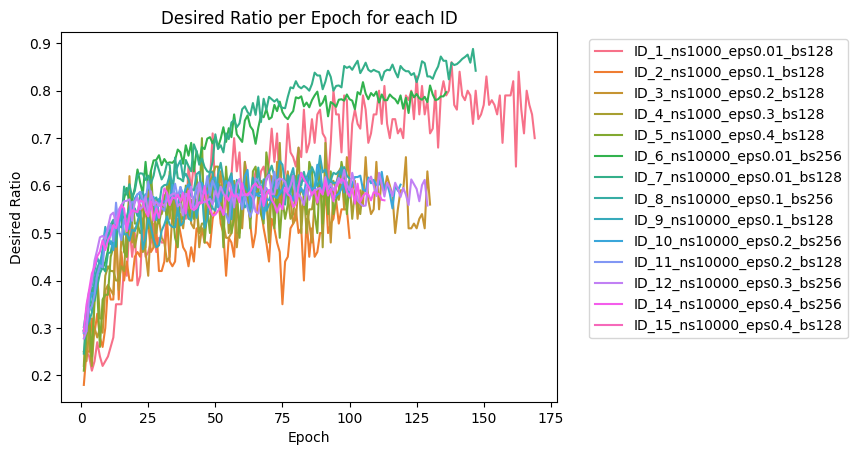

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt


unique_ids = fit_df['ID'].unique()
sorted_ids = sorted(unique_ids, key=lambda x: int(x.split('_')[1]))

# Plotting
sns.lineplot(data=fit_df, x='Epoch', y='desired_ratio', hue='ID', hue_order=sorted_ids)

plt.xlabel('Epoch')
plt.ylabel('Desired Ratio')
plt.title('Desired Ratio per Epoch for each ID')

# Place the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Show the plot
plt.show()


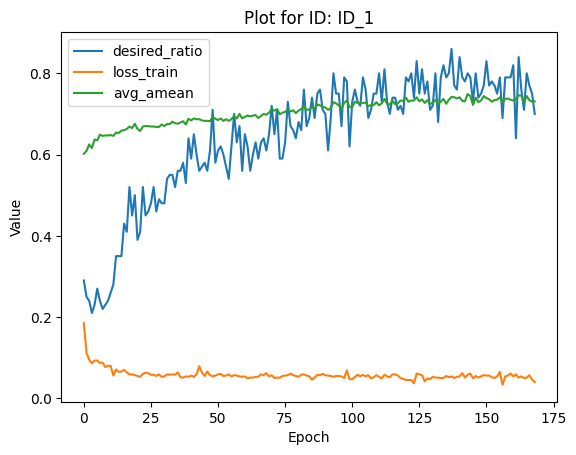

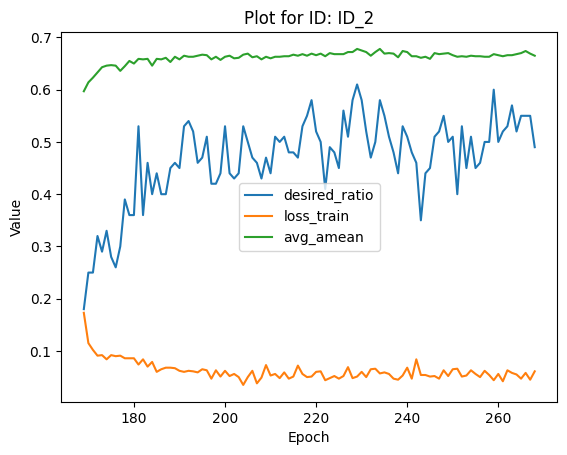

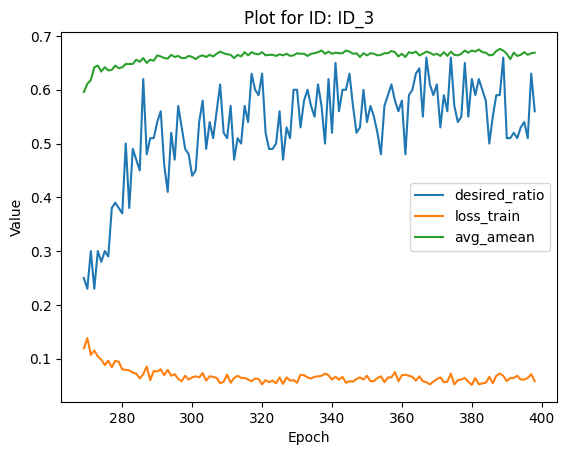

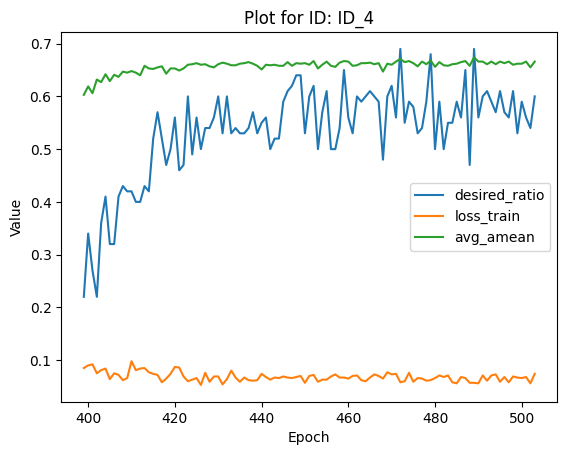

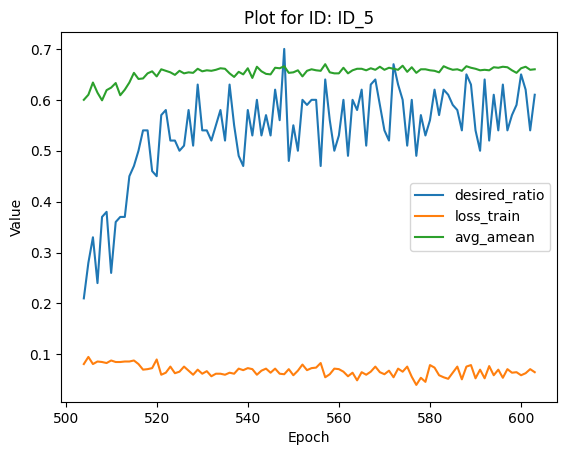

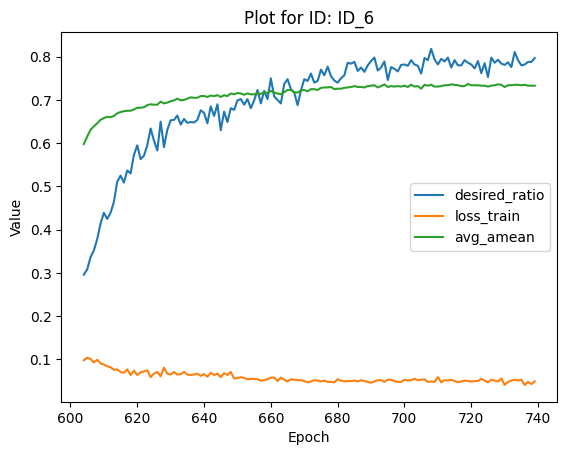

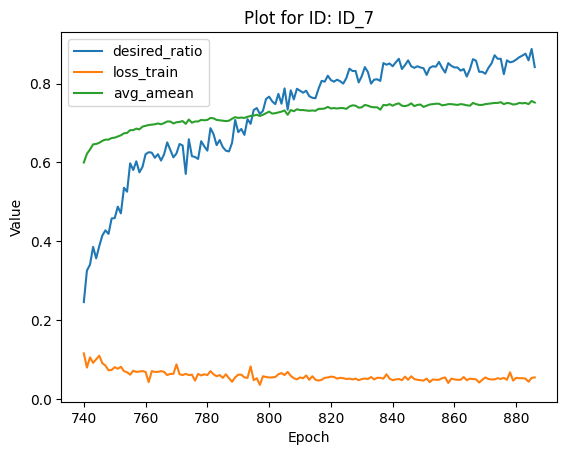

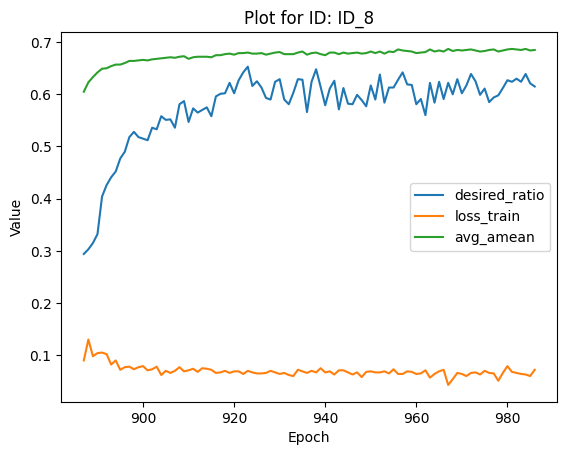

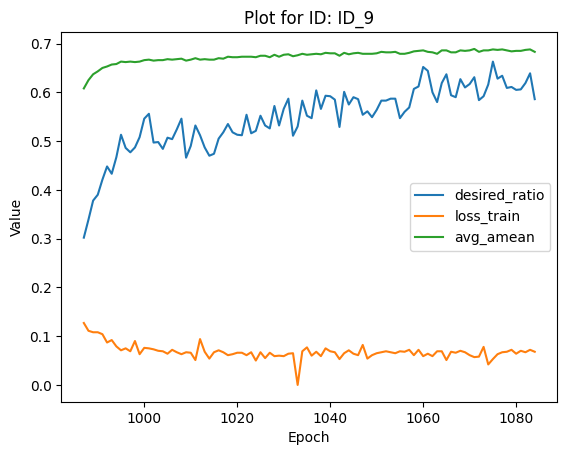

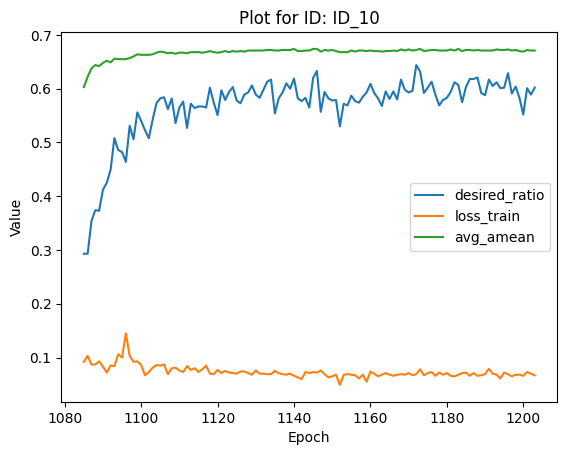

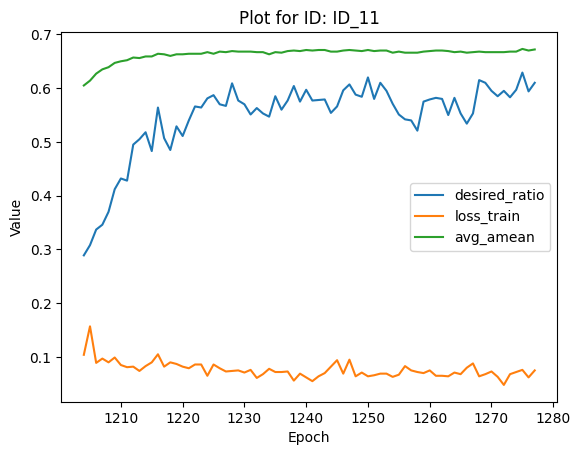

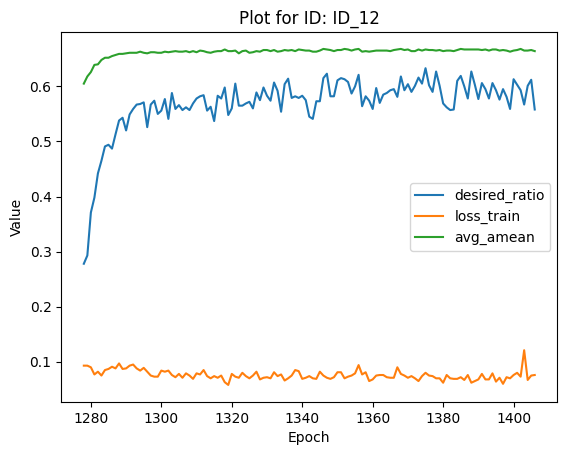

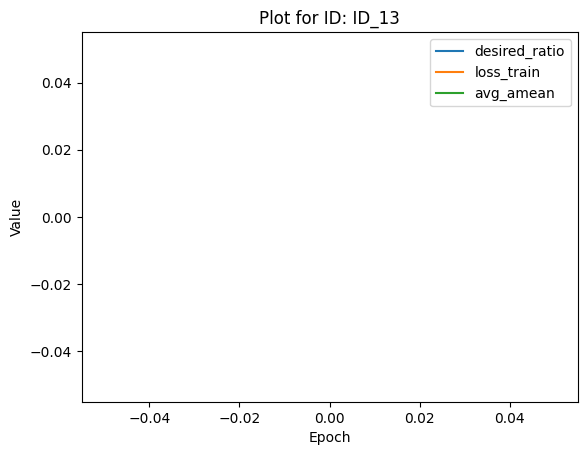

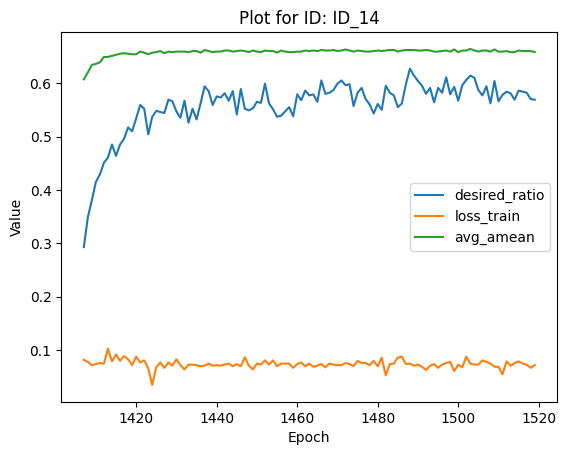

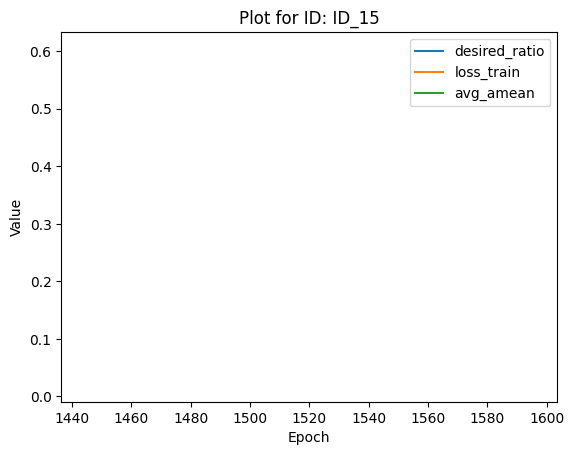

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Example list of IDs
ids_list = ['ID_1', 'ID_2', 'ID_3','ID_4','ID_5','ID_6','ID_7','ID_8','ID_9','ID_10','ID_11','ID_12','ID_13','ID_14','ID_15']

# Create an empty dictionary to store dataframes for each ID
id_dataframes = {}

# Iterate over each ID
for id_ in ids_list:
    # Filter fit_df for the current ID
    filtered_df = fit_df[fit_df['ID'] == id_]
    # Store the filtered dataframe for the current ID in the dictionary
    id_dataframes[id_] = filtered_df

# Iterate over each ID and plot the data
for id_, df in id_dataframes.items():
    # Plot the desired columns for the current ID
    df[['desired_ratio']].plot.line()
    # Set plot title and labels
    plt.title(f"Plot for ID: {id_}")
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    # Show the plot
    plt.show()


In [8]:
import pandas as pd
df_info = pd.read_csv(f'DrugEx_script/RL_ns10000_eps0.2_bs128_pt30_ne1000/CCR2_agent_fit.tsv', sep='\t')
df_info

,Epoch,valid_ratio,unique_ratio,desired_ratio,avg_amean,avg_gmean,loss_train,best_epoch
0,1,0.931,0.931,0.289,0.605,0.519,0.104,1
1,2,0.926,0.926,0.308,0.614,0.527,0.157,2
2,3,0.921,0.921,0.337,0.627,0.541,0.089,3
3,4,0.943,0.939,0.346,0.635,0.548,0.097,4
4,5,0.935,0.932,0.370,0.639,0.551,0.090,5
...,...,...,...,...,...,...,...,...
69,70,0.975,0.960,0.583,0.668,0.591,0.068,47
70,71,0.988,0.978,0.597,0.668,0.592,0.072,47
71,72,0.969,0.953,0.629,0.673,0.600,0.076,72
72,73,0.982,0.968,0.594,0.670,0.594,0.062,72


<Axes: >

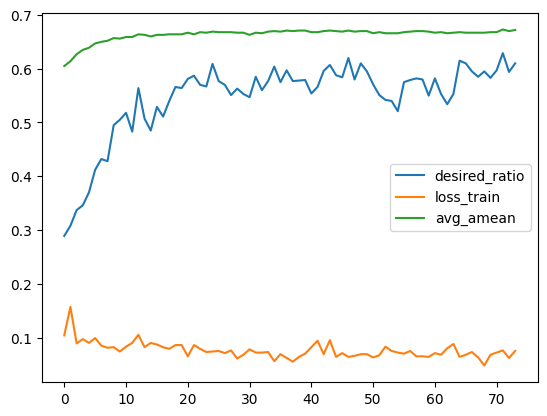

In [9]:
df_info[['desired_ratio', 'loss_train', 'avg_amean']].plot.line()